In [ ]:
%pip install matplotlib seaborn pandas numpy scikit-learn

/var/folders/pv/4pndnly93037qw_7vqb_7m3c0000gp/T/ipykernel_9436/3728968858.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = timeseries_df.resample('H', on='datetime').agg({'bucket_pred': 'max'}).reset_index()


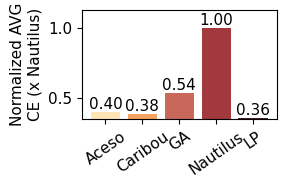

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Figure 8(a) - LOAD & PREP DATA
# -------------------------------------------------------------------
timeseries_df = pd.read_csv('workload-timeseries.csv', parse_dates=['datetime'])
methods_df    = pd.read_csv('Simulator/scripts/results/baseline_results.csv')

methods_df['carbon_emissions_g'] = (
    methods_df['carbon_emissions_g']
    .astype(str).str.replace('g', '', regex=False).astype(float)
)

methods_df['method'] = methods_df['experiment_id'].str.split('-').str[0]
methods_df['bucket'] = methods_df['experiment_id'].apply(
    lambda x: int(m.group(1)) if (m := re.search(r'load(\d+)', x)) else None
)

# -------------------------------------------------------------------
# HOURLY BUCKET + PER-METHOD CARBON
# -------------------------------------------------------------------
hourly_df = timeseries_df.resample('H', on='datetime').agg({'bucket_pred': 'max'}).reset_index()

methods = ['caribou', 'ga', 'aceso', 'lp']
for method in methods:
    sub = methods_df[methods_df['method'] == method]
    if method == 'lp':
        # LP only has one experiment
        lp_value = sub['carbon_emissions_g'].mean()
        hourly_df['carbon_lp'] = lp_value
    else:
        lookup = sub.groupby('bucket')['carbon_emissions_g'].mean().to_dict()
        hourly_df[f'carbon_{method}'] = hourly_df['bucket_pred'].map(lookup)

# -------------------------------------------------------------------
# AGGREGATE CARBON (scaled)
# -------------------------------------------------------------------
agg = {m: hourly_df[f'carbon_{m}'].sum() / 10000 for m in methods}

baseline_total = 1.0
agg_df = pd.DataFrame({
    'method': methods + ['nautilus'],
    'total_carbon': [agg[m] for m in methods] + [baseline_total],
})
agg_df['value_vs_nautilus'] = agg_df['total_carbon'] / baseline_total

custom_order = ['aceso', 'caribou', 'ga', 'nautilus', 'lp']
agg_df['method'] = pd.Categorical(agg_df['method'], categories=custom_order, ordered=True)
agg_df = agg_df.sort_values('method')

name_map = {'aceso': 'Aceso', 'caribou': 'Caribou', 'ga': 'GA',
            'nautilus': 'Nautilus', 'lp': 'LP'}
agg_df['method_pretty'] = agg_df['method'].map(name_map)

# -------------------------------------------------------------------
# PLOT
# -------------------------------------------------------------------
color_map = {
    'aceso': "moccasin", 'caribou': "sandybrown", 'ga': "#C8685B",
    'nautilus': "#A1393F", 'lp': "#4A1C20",
}

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 11, 'ytick.labelsize': 11})

plt.figure(figsize=(3.0, 2))
bars = plt.bar(agg_df['method_pretty'], agg_df['value_vs_nautilus'],
               color=[color_map[m] for m in agg_df['method']])

plt.ylabel("Normalized AVG\nCE (x Nautilus)")
plt.ylim(0.35, agg_df['value_vs_nautilus'].max() * 1.13)

for bar, value in zip(bars, agg_df['value_vs_nautilus']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{value:.2f}", ha='center', va='bottom', fontsize=11)

plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig("plots/Figure-8(a).pdf", bbox_inches="tight")
plt.show()

/var/folders/pv/4pndnly93037qw_7vqb_7m3c0000gp/T/ipykernel_9436/353833418.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = timeseries_df.resample('H', on='datetime').agg({'bucket_pred': 'max'}).reset_index()


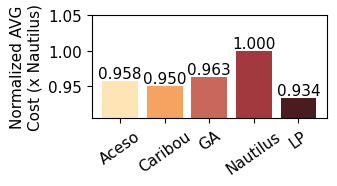

In [6]:
# -------------------------------------------------------------------
# Figure 8(b) - LOAD DATA
# -------------------------------------------------------------------
timeseries_df = pd.read_csv('workload-timeseries.csv', parse_dates=['datetime'])
methods_df    = pd.read_csv('Simulator/scripts/results/baseline_results.csv')

# clean numeric cost column
methods_df['total_cost_usd'] = (
    methods_df['total_cost_usd']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace('USD', '', regex=False)
    .str.replace('g', '', regex=False)
    .str.strip()
    .astype(float)
)

# -------------------------------------------------------------------
# PARSE METHOD NAME + BUCKET FROM experiment_id
# -------------------------------------------------------------------
methods_df['method'] = methods_df['experiment_id'].str.split('-').str[0]
methods_df['bucket'] = methods_df['experiment_id'].apply(
    lambda x: int(m.group(1)) if (m := re.search(r'load(\d+)', x)) else None
)

# -------------------------------------------------------------------
# HOURLY BUCKET + PER-METHOD COST
# -------------------------------------------------------------------
hourly_df = timeseries_df.resample('H', on='datetime').agg({'bucket_pred': 'max'}).reset_index()

methods = ['caribou', 'ga', 'aceso', 'lp']
for method in methods:
    sub = methods_df[methods_df['method'] == method]
    if method == 'lp':
        # LP only has one experiment
        lp_value = sub['total_cost_usd'].mean()
        hourly_df['cost_lp'] = lp_value
    else:
        lookup = sub.groupby('bucket')['total_cost_usd'].mean().to_dict()
        hourly_df[f'cost_{method}'] = hourly_df['bucket_pred'].map(lookup)

# -------------------------------------------------------------------
# AVERAGE COST PER METHOD (scaled) + NAUTILUS/LP BASELINE
# -------------------------------------------------------------------
avg = {m: hourly_df[f'cost_{m}'].mean() / 100 for m in methods}

baseline_avg = 1.0
cost_df = pd.DataFrame({
    'method': methods + ['nautilus'],
    'avg_cost': [avg[m] for m in methods] + [baseline_avg],
})
cost_df['value_vs_nautilus'] = cost_df['avg_cost'] / baseline_avg

# -------------------------------------------------------------------
# LABELS + ORDER
# -------------------------------------------------------------------
name_map = {'aceso': 'Aceso', 'caribou': 'Caribou', 'ga': 'GA',
            'nautilus': 'Nautilus', 'lp': 'LP'}
cost_df['method_pretty'] = cost_df['method'].map(name_map)

desired_order = ["Aceso", "Caribou", "GA", "Nautilus", "LP"]
cost_df['method_pretty'] = pd.Categorical(
    cost_df['method_pretty'], categories=desired_order, ordered=True
)
cost_df = cost_df.sort_values('method_pretty')

# -------------------------------------------------------------------
# PLOT
# -------------------------------------------------------------------
color_map = {
    'aceso': "moccasin", 'caribou': "sandybrown", 'ga': "#C8685B",
    'nautilus': "#A1393F", 'lp': "#4A1C20",
}

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 11, 'ytick.labelsize': 11})

plt.figure(figsize=(3.5, 2))
bars = plt.bar(cost_df['method_pretty'], cost_df['value_vs_nautilus'],
               color=[color_map[m] for m in cost_df['method']])

plt.ylabel("Normalized AVG\nCost (x Nautilus)")
ymax, ymin = cost_df['value_vs_nautilus'].max(), cost_df['value_vs_nautilus'].min()
plt.ylim(ymin * 0.97, ymax * 1.05)

for bar, val in zip(bars, cost_df['value_vs_nautilus']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.3f}", ha='center', va='bottom', fontsize=11)

plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig("plots/Figure-8(b).pdf", bbox_inches="tight")
plt.show()

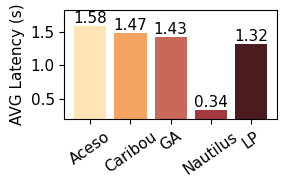

In [14]:
# -------------------------------------------------------------------
# Figure 8(c) - LOAD DATA
# -------------------------------------------------------------------
timeseries_df = pd.read_csv('workload-timeseries.csv', parse_dates=['datetime'])
methods_df    = pd.read_csv('Simulator/scripts/results/baseline_results.csv')

# ms -> s
methods_df['total_latency_s'] = (
    methods_df['total_latency_ms']
    .astype(str).str.replace(',', '', regex=False)
    .astype(float).div(1000.0).round(3)
)

# -------------------------------------------------------------------
# PARSE METHOD + BUCKET FROM experiment_id
# -------------------------------------------------------------------
methods_df['method'] = methods_df['experiment_id'].str.split('-').str[0]
methods_df['bucket'] = methods_df['experiment_id'].apply(
    lambda x: int(m.group(1)) if (m := re.search(r'load(\d+)', x)) else None
)

# -------------------------------------------------------------------
# HOURLY BUCKET + PER-METHOD LATENCY
# -------------------------------------------------------------------
hourly_df = timeseries_df.resample('h', on='datetime').agg({'bucket_pred': 'max'}).reset_index()

methods = ['caribou', 'ga', 'aceso', 'lp']
for method in methods:
    sub = methods_df[methods_df['method'] == method]
    if method == 'lp':
        # LP only has one experiment
        lp_value = sub['total_latency_s'].mean() * 2
        hourly_df['latency_lp'] = lp_value
    else:
        lookup = sub.groupby('bucket')['total_latency_s'].mean().to_dict()
        hourly_df[f'latency_{method}'] = hourly_df['bucket_pred'].map(lookup)

# -------------------------------------------------------------------
# AVERAGE LATENCY PER METHOD + NAUTILUS/LP BASELINE
# -------------------------------------------------------------------
agg = {m: hourly_df[f'latency_{m}'].mean() for m in methods}

baseline = 0.34
lat_df = pd.DataFrame({
    'method': methods + ['nautilus'],
    'avg_latency': [agg[m] for m in methods] + [baseline],
})

# -------------------------------------------------------------------
# LABELS + ORDER
# -------------------------------------------------------------------
name_map = {'aceso': 'Aceso', 'caribou': 'Caribou', 'ga': 'GA',
            'nautilus': 'Nautilus', 'lp': 'LP'}
lat_df['method_pretty'] = lat_df['method'].map(name_map)

desired_order = ["Aceso", "Caribou", "GA", "Nautilus", "LP"]
lat_df['method_pretty'] = pd.Categorical(
    lat_df['method_pretty'], categories=desired_order, ordered=True
)
lat_df = lat_df.sort_values('method_pretty')

# -------------------------------------------------------------------
# PLOT
# -------------------------------------------------------------------
color_map = {
    'aceso': "moccasin", 'caribou': "sandybrown", 'ga': "#C8685B",
    'nautilus': "#A1393F", 'lp': "#4A1C20",
}

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 11, 'ytick.labelsize': 11})

plt.figure(figsize=(3.0, 2))
bars = plt.bar(lat_df['method_pretty'], lat_df['avg_latency'],
               color=[color_map[m] for m in lat_df['method']])

plt.ylabel("AVG Latency (s)")
ymax, ymin = lat_df['avg_latency'].max(), lat_df['avg_latency'].min()
plt.ylim(ymin * 0.6, ymax * 1.15)

for bar, val in zip(bars, lat_df['avg_latency']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.2f}", ha='center', va='bottom', fontsize=11)

plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig("plots/Figure-8(c).pdf", bbox_inches="tight")
plt.show()

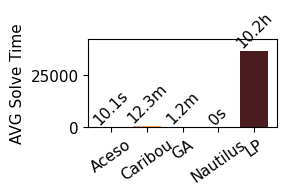

In [26]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Figure 8(d) - LOAD DATA
# -------------------------------------------------------------------
timeseries_df = pd.read_csv('workload-timeseries.csv', parse_dates=['datetime'])
methods_df    = pd.read_csv('Simulator/scripts/results/baseline_results.csv')

methods_df['solve_time_seconds'] = (
    methods_df['solve_time_seconds']
    .astype(str).str.replace(',', '', regex=False)
    .astype(float).round(3)
)

methods_df['method'] = methods_df['experiment_id'].str.split('-').str[0]
methods_df['bucket'] = methods_df['experiment_id'].apply(
    lambda x: int(m.group(1)) if (m := re.search(r'load(\d+)', x)) else None
)

# -------------------------------------------------------------------
# HOURLY BUCKET + PER-METHOD SOLVE TIME
# -------------------------------------------------------------------
hourly_df = timeseries_df.resample('h', on='datetime').agg({'bucket_pred': 'max'}).reset_index()

methods = ['caribou', 'ga', 'aceso', 'lp']
for method in methods:
    sub = methods_df[methods_df['method'] == method]
    if method == 'lp':
        # LP only has one experiment (load5); apply its value to every bucket
        lp_value = sub['solve_time_seconds'].mean()
        hourly_df['solve_lp'] = lp_value
    else:
        lookup = sub.groupby('bucket')['solve_time_seconds'].mean().to_dict()
        hourly_df[f'solve_{method}'] = hourly_df['bucket_pred'].map(lookup)

# -------------------------------------------------------------------
# AVERAGE SOLVE TIME PER METHOD + NAUTILUS/LP = 0
# -------------------------------------------------------------------
agg = {m: hourly_df[f'solve_{m}'].mean() for m in methods}

solve_df = pd.DataFrame({
    'method': methods + ['nautilus'],
    'avg_solve': [agg[m] for m in methods] + [0.0],
})

name_map = {'aceso': 'Aceso', 'caribou': 'Caribou', 'ga': 'GA',
            'nautilus': 'Nautilus', 'lp': 'LP'}
solve_df['method_pretty'] = solve_df['method'].map(name_map)

desired_order = ["Aceso", "Caribou", "GA", "Nautilus", "LP"]
solve_df['method_pretty'] = pd.Categorical(
    solve_df['method_pretty'], categories=desired_order, ordered=True
)
solve_df = solve_df.sort_values('method_pretty')

# -------------------------------------------------------------------
# PLOT
# -------------------------------------------------------------------
def fmt_label(seconds):
    if seconds >= 3600: return seconds / 3600.0, "h"
    if seconds >= 60:   return seconds / 60.0,   "m"
    return seconds, "s"

color_map = {
    'aceso': "moccasin", 'caribou': "sandybrown", 'ga': "#C8685B",
    'nautilus': "#A1393F", 'lp': "#4A1C20",
}

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 11, 'ytick.labelsize': 11})

plt.figure(figsize=(3.0, 2))
bars = plt.bar(solve_df['method_pretty'], solve_df['avg_solve'],
               color=[color_map[m] for m in solve_df['method']])

plt.ylabel("AVG Solve Time")
#plt.yscale('log')
plt.ylim(0, solve_df['avg_solve'].max() * 1.15)

for bar, method, val in zip(bars, solve_df['method'], solve_df['avg_solve']):
    if method == 'nautilus':
        label = "0s"
    else:
        display, unit = fmt_label(val)
        label = f"{display:.1f}{unit}"
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             label, ha='center', va='bottom', fontsize=11, rotation=45)

plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig("plots/Figure-8(d).pdf", bbox_inches="tight")
plt.show()

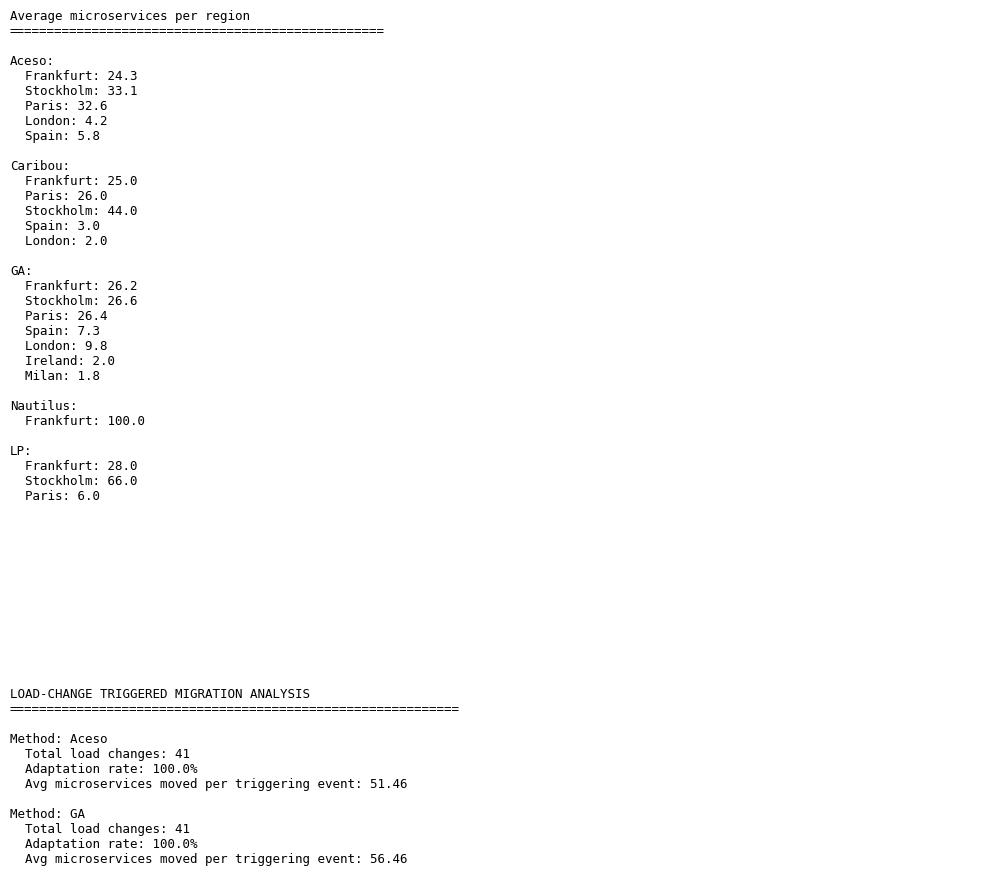

In [32]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================================================================
# SHARED SETUP
# ===================================================================
methods_df = pd.read_csv('Simulator/scripts/results/baseline_results.csv')
methods_df['method'] = methods_df['experiment_id'].apply(lambda x: x.split('-')[0])

def extract_bucket(expid):
    m = re.search(r'load(\d+)', expid)
    return int(m.group(1)) if m else None

methods_df['bucket'] = methods_df['experiment_id'].apply(extract_bucket)


def parse_assignment(assignment_str):
    """Parse assignment string 'msX:regionA; msY:regionB' into a dict."""
    if pd.isna(assignment_str):
        return {}
    assignments = {}
    for part in assignment_str.split(';'):
        if ':' in part:
            ms, region = part.split(':')
            assignments[ms.strip()] = region.strip()
    return assignments


def count_per_region(assignment_str):
    """Return {region: count} for one assignment string."""
    a = parse_assignment(assignment_str)
    counts = {}
    for region in a.values():
        counts[region] = counts.get(region, 0) + 1
    return counts


name_map = {
    'aceso': 'Aceso',
    'caribou': 'Caribou',
    'ga': 'GA',
    'nautilus': 'Nautilus',
    'lp': 'LP',
}

# ===================================================================
# Table 2(a) — AVERAGE MICROSERVICES PER REGION
# ===================================================================
target_methods_2a = ['aceso', 'caribou', 'ga']

region_avgs = {}

for method in target_methods_2a:
    sub = methods_df[methods_df['method'] == method]

    bucket_assignment = (
        sub.dropna(subset=['bucket'])
        .groupby('bucket')['assignment']
        .first()
        .to_dict()
    )

    assignments = hourly_df['bucket_pred'].map(bucket_assignment).tolist()

    totals = {}
    hours_counted = 0
    for a in assignments:
        if not isinstance(a, str):
            continue
        counts = count_per_region(a)
        if not counts:
            continue
        for region, c in counts.items():
            totals[region] = totals.get(region, 0) + c
        hours_counted += 1

    if hours_counted > 0:
        region_avgs[method] = {r: totals[r] / hours_counted for r in totals}
    else:
        region_avgs[method] = {}

# LP: read from file (load5 broadcast to all buckets), same as other figures
lp_sub = methods_df[methods_df['method'] == 'lp']
if not lp_sub.empty:
    lp_assignment = lp_sub['assignment'].dropna().iloc[0] if lp_sub['assignment'].notna().any() else None
    if lp_assignment is not None:
        lp_counts = count_per_region(lp_assignment)
        region_avgs['lp'] = {r: float(c) for r, c in lp_counts.items()}
    else:
        region_avgs['lp'] = {}
else:
    region_avgs['lp'] = {}

# Nautilus: dummy 100% Frankfurt
region_avgs['nautilus'] = {'Frankfurt': 100.0}

# ===================================================================
# Table 2(b) — LOAD-CHANGE–TRIGGERED MIGRATION ANALYSIS
# ===================================================================
results = {}

target_methods_2b = ['aceso', 'ga']   # Caribou & LP removed

hourly_buckets = timeseries_df.resample('h', on='datetime').agg({
    'bucket_true': 'max'
}).reset_index()

for method in target_methods_2b:
    sub = methods_df[methods_df['method'] == method]

    bucket_assignment = (
        sub.dropna(subset=['bucket'])
        .groupby('bucket')['assignment']
        .first()
        .to_dict()
    )

    assignments = hourly_buckets['bucket_true'].map(bucket_assignment).tolist()
    loads = hourly_buckets['bucket_true'].tolist()

    load_change_indices = [i for i in range(1, len(loads)) if loads[i] != loads[i - 1]]
    total_load_changes = len(load_change_indices)

    migration_counts = []
    prev = parse_assignment(assignments[0]) if assignments else {}

    for i in load_change_indices:
        current = parse_assignment(assignments[i])
        all_ms = set(prev.keys()) | set(current.keys())
        migrations_this_change = sum(
            current.get(ms, prev.get(ms)) != prev.get(ms)
            for ms in all_ms
        )
        if migrations_this_change > 0:
            migration_counts.append(migrations_this_change)
        prev = current

    avg_ms_moved = np.mean(migration_counts) if migration_counts else 0

    adaptation_rate = (
        (len(migration_counts) / total_load_changes) * 100
        if total_load_changes > 0 else 0
    )

    results[method] = {
        "total_load_changes": total_load_changes,
        "adaptation_rate": adaptation_rate,
        "avg_ms_moved_per_trigger": avg_ms_moved,
    }

# ===================================================================
# BUILD TEXT BLOCKS
# ===================================================================
lines_2a = ["Average microservices per region", "=" * 50, ""]
for method in ['aceso', 'caribou', 'ga', 'nautilus', 'lp']:
    lines_2a.append(f"{name_map[method]}:")
    if region_avgs[method]:
        for region, avg in region_avgs[method].items():
            lines_2a.append(f"  {region}: {avg:.1f}")
    else:
        lines_2a.append("  (no data)")
    lines_2a.append("")

lines_2b = ["LOAD-CHANGE TRIGGERED MIGRATION ANALYSIS", "=" * 60, ""]
for method, r in results.items():
    lines_2b.append(f"Method: {name_map.get(method, method)}")
    lines_2b.append(f"  Total load changes: {r['total_load_changes']}")
    if isinstance(r['adaptation_rate'], str):
        lines_2b.append(f"  Adaptation rate: {r['adaptation_rate']}")
    else:
        lines_2b.append(f"  Adaptation rate: {r['adaptation_rate']:.1f}%")
    if isinstance(r['avg_ms_moved_per_trigger'], str):
        lines_2b.append(f"  Avg microservices moved per triggering event: {r['avg_ms_moved_per_trigger']}%")
    else:
        lines_2b.append(f"  Avg microservices moved per triggering event: {r['avg_ms_moved_per_trigger']:.2f}")
    lines_2b.append("")

# ===================================================================
# RENDER AS A SINGLE FIGURE
# ===================================================================
fig = plt.figure(figsize=(11, 8.5))
fig.patch.set_facecolor('white')

fig.text(0.02, 0.98, "\n".join(lines_2a),
         va='top', ha='left', family='monospace', fontsize=9)

line_height_frac = 0.022
y_start_2b = 0.98 - line_height_frac * len(lines_2a) - 0.05

fig.text(0.02, y_start_2b, "\n".join(lines_2b),
         va='top', ha='left', family='monospace', fontsize=9)

plt.axis('off')
plt.savefig("plots/Table-2.pdf", bbox_inches="tight", facecolor='white')
plt.show()

/var/folders/pv/4pndnly93037qw_7vqb_7m3c0000gp/T/ipykernel_9436/1240875100.py:61: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 3.9 * 60)


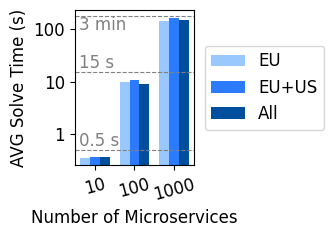

In [36]:
# Scalability Analysis - Figure 9a
import numpy as np
# Load CSV
df = pd.read_csv("Simulator/scripts/results/scalability_results.csv")
df = df.sort_values("solve_time").groupby(["num_ms", "slo", "candidate_regions"], as_index=False).head(3)
#df = df.sort_values("solve_time").groupby(["num_ms", "slo"], as_index=False).head(3)
# Define region sets
EU = {"Paris", "Stockholm", "London", "Spain", "Ireland", "Milan"}
EU_US = EU | {"Northern Virginia", "Ohio", "Mexico City", "Montreal", "Calgary", "Northern California"}

methods = ["10", "100", "1000"]
regions = ["EU", "EU+US", "All"]
colors = ["#99C8FF", "#2C7BFF", "#004E9E"]

# SLO filter per method
slo_map = {"10": 1650, "100": 1650, "1000": 7000}

# Compute averages
avg_data = {}
for m in methods:
    sub = df[(df["num_ms"] == int(m)) & (df["slo"] == slo_map[m])]
    avg_data[m] = []
    for region in regions:
        if region == "EU":
            mask = sub["candidate_regions"].apply(lambda r: set(r.split("|")) == EU)
        elif region == "EU+US":
            mask = sub["candidate_regions"].apply(lambda r: set(r.split("|")) == EU_US)
        else:
            mask = sub["candidate_regions"].apply(lambda r: set(r.split("|")) not in (EU, EU_US))
        avg_data[m].append(sub.loc[mask, "solve_time"].mean())

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(3.5, 2.5))

for i, region in enumerate(regions):
    vals = [avg_data[m][i] for m in methods]
    plt.bar(x + (i - 1) * width, vals, width, label=region, color=colors[i])

plt.xticks(x, methods, fontsize=12, rotation=15)
plt.ylabel("AVG Solve Time (s)", fontsize=12)
plt.xlabel("Number of Microservices", fontsize=12)

plt.axhline(y=0.5, linestyle='--', linewidth=0.8, color='gray')
plt.axhline(y=15, linestyle='--', linewidth=0.8, color='gray')
plt.axhline(y=180, linestyle='--', linewidth=0.8, color='gray')

plt.text(-0.4, 15, "15 s", color="gray", fontsize=12, va='bottom')
plt.text(-0.4, 0.5, "0.5 s", color="gray", fontsize=12, va='bottom')
plt.text(-0.4, 180, "3 min", color="gray", fontsize=12, va='top')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=12, frameon=True)
plt.yscale('log')

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_locator(ticker.FixedLocator([1, 10, 100]))
plt.gca().yaxis.set_minor_locator(ticker.NullLocator())
plt.yticks([1, 10, 100], ["1", "10", "100"], fontsize=12)

plt.ylim(0, 3.9 * 60)
plt.tight_layout()
plt.savefig("plots/Figure-9(a).pdf", bbox_inches="tight")
plt.show()

/var/folders/pv/4pndnly93037qw_7vqb_7m3c0000gp/T/ipykernel_9436/921241140.py:47: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 3.8 * 60)


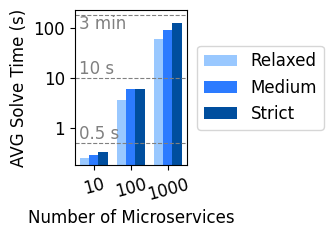

In [34]:
# Scalability Analysis - Figure 9b

df = pd.read_csv("Simulator/scripts/results/scalability_results.csv")
df = df.sort_values("solve_time").groupby(["num_ms", "slo"], as_index=False).head(3)
methods = ["10", "100", "1000"]
regions = ["Relaxed", "Medium", "Strict"]
colors = ["#99C8FF", "#2C7BFF", "#004E9E"]

# Build avg_data from CSV
avg_data = {}
for m in methods:
    sub = df[df["num_ms"] == int(m)]
    slos = sorted(sub["slo"].unique())
    # Relaxed = smallest SLO, Strict = largest, Medium = in-between
    slo_map = {"Relaxed": slos[0], "Medium": slos[1], "Strict": slos[-1]}
    avg_data[m] = [sub.loc[sub["slo"] == slo_map[r], "solve_time"].mean() for r in regions]

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(3.5, 2.5))

for i, region in enumerate(regions):
    vals = [avg_data[m][i] for m in methods]
    plt.bar(x + (i - 1) * width, vals, width, label=region, color=colors[i])

plt.xticks(x, methods, fontsize=12, rotation=15)
plt.ylabel("AVG Solve Time (s)", fontsize=12)
plt.xlabel("Number of Microservices", fontsize=12)

plt.axhline(y=0.5, linestyle='--', linewidth=0.8, color='gray')
plt.axhline(y=10, linestyle='--', linewidth=0.8, color='gray')
plt.axhline(y=3 * 60, linestyle='--', linewidth=0.8, color='gray')

plt.text(-0.4, 10, "10 s", color="gray", fontsize=12, va='bottom')
plt.text(-0.4, 0.5, "0.5 s", color="gray", fontsize=12, va='bottom')
plt.text(-0.4, 3 * 60, "3 min", color="gray", fontsize=12, va='top')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=12, frameon=True)
plt.yscale('log')

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_locator(ticker.FixedLocator([1, 10, 100]))
plt.gca().yaxis.set_minor_locator(ticker.NullLocator())
plt.yticks([1, 10, 100], ["1", "10", "100"], fontsize=12)

plt.ylim(0, 3.8 * 60)
plt.tight_layout()
plt.savefig("plots/Figure-9(b).pdf", bbox_inches="tight")
plt.show()

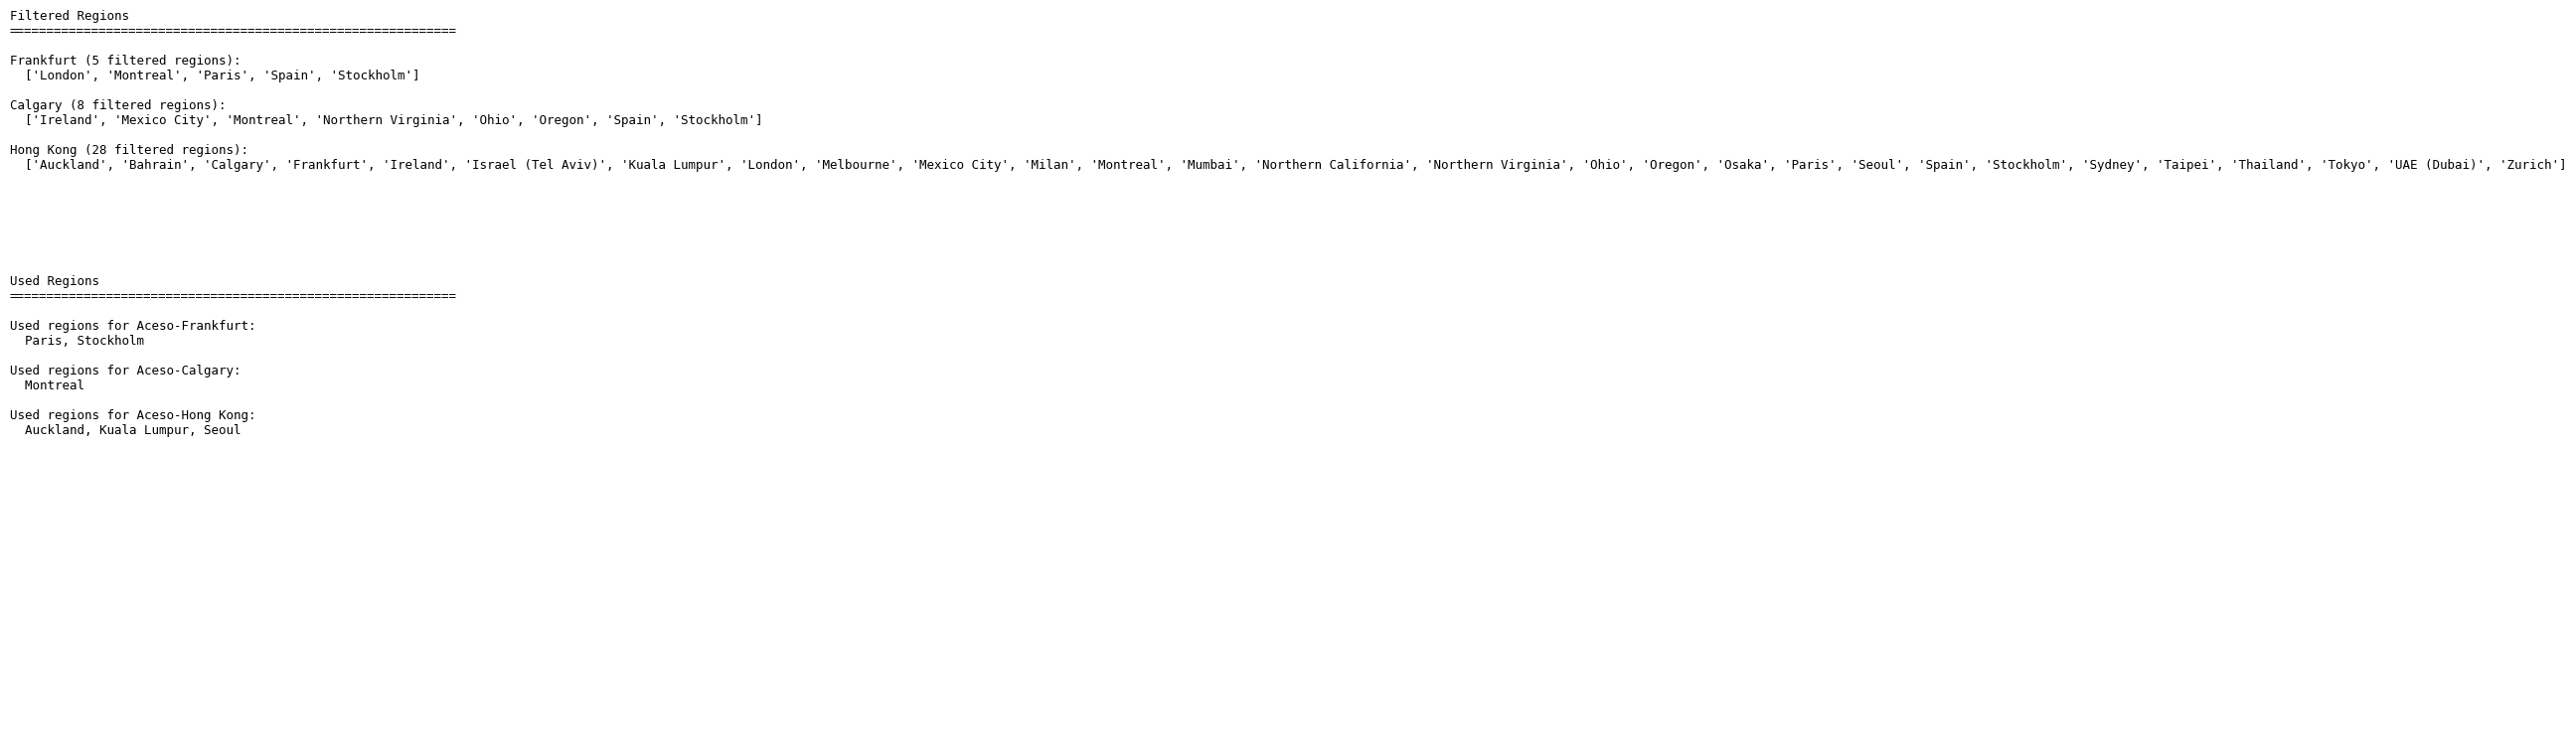

In [38]:
#FIGURE 6a - TODO TEST
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# -------------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------------
df = pd.read_csv('Simulator/scripts/results/region_filtering_results.csv')

# -------------------------------------------------------------------
# BLOCK 1 — Filtered Regions (cities)
# -------------------------------------------------------------------
target_cities = ['Frankfurt', 'Calgary', 'Hong Kong']
lines_block1 = ["Filtered Regions", "=" * 60, ""]

for city in target_cities:
    city_row = df[df['base_region'] == city]
    if not city_row.empty:
        filtered_str = city_row['filtered_regions'].values[0]
        regions = [r.strip() for r in filtered_str.split(',')]
        regions = [r for r in regions if r != city]
        lines_block1.append(f"{city} ({len(regions)} filtered regions):")
        lines_block1.append(f"  {regions}")
        lines_block1.append("")
    else:
        lines_block1.append(f"{city}: Not found in CSV")
        lines_block1.append("")

# -------------------------------------------------------------------
# BLOCK 2 — Used Regions (Aceso-*)
# -------------------------------------------------------------------
target_regions = ['Aceso-Frankfurt', 'Aceso-Calgary', 'Aceso-Hong Kong']
lines_block2 = ["Used Regions", "=" * 60, ""]

for region in target_regions:
    region_row = df[df['base_region'] == region]
    if not region_row.empty:
        filtered_str = region_row['filtered_regions'].values[0]
        regions = [r.strip() for r in filtered_str.split(',')]
        base_city = region.split('-', 1)[1] if '-' in region else region
        regions = [r for r in regions if r != base_city]
        lines_block2.append(f"Used regions for {region}:")
        lines_block2.append(f"  {', '.join(regions)}")
        lines_block2.append("")
    else:
        lines_block2.append(f"Used regions for {region}:")
        lines_block2.append(f"  Not found in CSV")
        lines_block2.append("")

# -------------------------------------------------------------------
# RENDER BOTH BLOCKS AS TEXT ON A SINGLE FIGURE
# -------------------------------------------------------------------
fig = plt.figure(figsize=(11, 8.5))   # letter size
fig.patch.set_facecolor('white')

# Top block
fig.text(0.02, 0.98, "\n".join(lines_block1),
         va='top', ha='left', family='monospace', fontsize=9)

# Bottom block — offset below the top block
# Estimate vertical space used by block1 based on number of lines
line_height_frac = 0.022
y_start_block2 = 0.98 - line_height_frac * len(lines_block1) - 0.05

fig.text(0.02, y_start_block2, "\n".join(lines_block2),
         va='top', ha='left', family='monospace', fontsize=9)

plt.axis('off')
plt.savefig("plots/Figure-6a.pdf", bbox_inches="tight", facecolor='white')
plt.show()

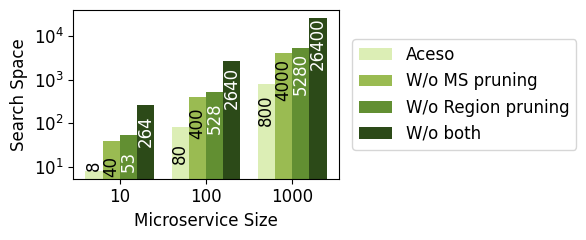

In [ ]:
#Figure 10

import matplotlib.pyplot as plt
import numpy as np

# Microservice sizes (x-axis groups)
MS_values = [10, 100, 1000]

# Categories (bars within each group)
categories = ["Aceso",  "W/o MS pruning", "W/o Region pruning", "W/o both"]

# Colors for the bars
colors = ["#DCEEB5", "#9ABB52", "#628F32", "#2C4A18"]

# Formulas for each category
formulas = [
    #pinned MS * movable MS * # of candidate regions * MS size
    #pinned MS is always 20% (DBs, frontends etc.)
    #20% movable MS due to tight SLO
    # of candidate regions after filtering is 5 for Frankfurt as shown above 
    # ('London', 'Montreal', 'Paris', 'Spain', 'Stockholm')
    # vs 8 for entire EU set
    lambda MS: 0.8 * 0.2 * 5 * MS,  # Aceso
    lambda MS: 0.8 * 1 * 5 * MS,        # W/o MS pruning
    lambda MS: 0.8 * 0.2 * 33 * MS,  # W/o region pruning
    lambda MS: 0.8 * 1* 33 * MS         # W/o both
]

# Calculate values for each MS size
values = []
for MS in MS_values:
    group_values = [formula(MS) for formula in formulas]
    values.append(group_values)

values = np.array(values)  # shape (3,4)

# Bar width and positions
bar_width = 0.2
x = np.arange(len(MS_values))

# Create figure
fig, ax = plt.subplots(figsize=(6,2.5))

# Plot each category
for i in range(len(categories)):
    bars = ax.bar(x + i*bar_width, values[:,i], width=bar_width, color=colors[i], label=categories[i])
    
    # Add labels
    for j, (bar, val) in enumerate(zip(bars, values[:,i])):
        height = bar.get_height()
        # Special case: first two columns for 10 MS (x=0)
        if i in [0] and j == 0:  # first two categories, 10 MS
            ax.text(bar.get_x() + bar.get_width()/2, height, f'{val:.0f}',
                    ha='center', va='bottom', color='black', fontsize=12, rotation=90)
        else:  # default positions
            ax.text(bar.get_x() + bar.get_width()/2, height/4, f'{val:.0f}',
                    ha='center', va='center', color='white' if i > 1 else 'black', fontsize=12, rotation=90)

# Labels and ticks
ax.set_xlabel("Microservice Size", fontsize=12)
ax.set_ylabel("Search Space", fontsize=12)
ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels(MS_values, fontsize=12)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    fontsize=12,
    frameon=True
)
plt.yscale('log')

import matplotlib.ticker as ticker
# Remove all automatic ticks
plt.gca().yaxis.set_major_locator(ticker.FixedLocator([1, 10, 100]))
plt.gca().yaxis.set_minor_locator(ticker.NullLocator())

# Set your own labels
plt.yticks([10, 100, 1000,10000],[r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$'], fontsize=12)

plt.tight_layout()
plt.savefig("plots/Figure-10.pdf", bbox_inches="tight")
plt.show()


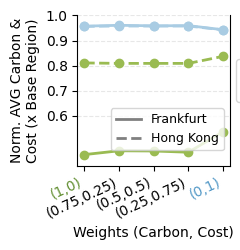

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import csv
from collections import defaultdict
from matplotlib.lines import Line2D

# Read data from CSV, averaging duplicates by (region, carbon_weight, cost_weight)
buckets = defaultdict(lambda: {'carbon': [], 'cost': []})
with open('Simulator/scripts/results/weight_sensitivity_results.csv', 'r') as f:
    for row in csv.DictReader(f):
        key = (row['base_region'].strip(),
               float(row['carbon_weight']),
               float(row['cost_weight']))
        buckets[key]['carbon'].append(float(row['carbon_remaining_pct']) / 100.0)
        buckets[key]['cost'].append(float(row['cost_remaining_pct'])   / 100.0)

data = {k: {'carbon': sum(v['carbon']) / len(v['carbon']),
            'cost':   sum(v['cost'])   / len(v['cost'])}
        for k, v in buckets.items()}

# Weight configurations and their x-axis labels
weight_configs = [(1.0, 0.0), (0.75, 0.25), (0.5, 0.5), (0.25, 0.75), (0.0, 1.0)]
weight_labels  = ['(1,0)', '(0.75,0.25)', '(0.5,0.5)', '(0.25,0.75)', '(0,1)']

# Extract series for each region (default 1.0 if missing)
def series(region, field):
    return [data.get((region, cw, kw), {}).get(field, 1.0)
            for cw, kw in weight_configs]

# Create the plot
fig, ax = plt.subplots(figsize=(2.5, 2.6))
ax.spines['top'].set_visible(False)

# Frankfurt (solid), Hong Kong (dashed)
for region, style in [('Frankfurt', '-'), ('Hong Kong', '--')]:
    ax.plot(weight_labels, series(region, 'carbon'), 'o' + style,
            color='#9ABB52', linewidth=2, markersize=6,
            label='Carbon' if style == '-' else '_nolegend_')
    ax.plot(weight_labels, series(region, 'cost'), 'o' + style,
            color='#A9CCE3', linewidth=2, markersize=6,
            label='Cost' if style == '-' else '_nolegend_')

# Customize the plot
ax.set_xlabel('Weights (Carbon, Cost)', fontsize=10)
ax.set_ylabel('Norm. AVG Carbon &\nCost (x Base Region)', fontsize=10)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(range(len(weight_labels)))
ax.set_xticklabels(weight_labels, rotation=25, ha='right', fontsize=10)
ax.set_yticks(np.arange(0.6, 1.01, 0.1))
ax.set_ylim(0.4, 1)

# Legends
legend1 = ax.legend(handles=[
    Line2D([0], [0], color='#9ABB52', linewidth=2, marker='o', markersize=6, label='Carbon'),
    Line2D([0], [0], color='#A9CCE3', linewidth=2, marker='o', markersize=6, label='Cost'),
], loc='best', fontsize=9)
ax.add_artist(legend1)
legend1.set_bbox_to_anchor((1, 0.75))

legend2 = ax.legend(handles=[
    Line2D([0], [0], color='gray', linewidth=2, linestyle='-',  label='Frankfurt'),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='Hong Kong'),
], loc='lower right', fontsize=9)
legend2.set_bbox_to_anchor((1, 0.06))

# Color x-tick labels by dominant weight
for tick in ax.get_xticklabels():
    t = tick.get_text()
    tick.set_color('#628F32' if t == '(1,0)' else
                   '#5499C7' if t == '(0,1)' else 'black')

plt.tight_layout()
plt.savefig('plots/Figure-12(a).pdf', bbox_inches='tight')
plt.show()

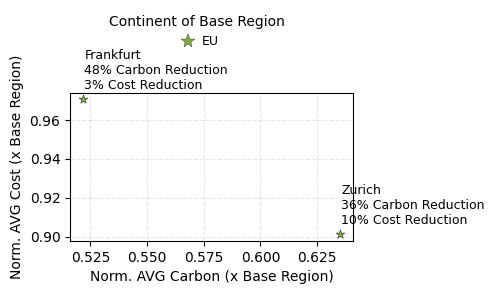

In [ ]:
# Figure 12b - Generalizability

import matplotlib.pyplot as plt
import numpy as np
import csv
import os

# Read data from generalizability_results.csv
csv_file = 'Simulator/scripts/results/generalizability_results.csv'

if not os.path.isfile(csv_file):
    raise FileNotFoundError(f"Could not find {csv_file}. Please run the optimizer with -gen first.")

# Map base region names to continent, color and marker
region_style = {
    # Europe
    'Frankfurt': ('Europe', '#7FA844', '*'),
    'Milan': ('Europe', '#7FA844', '*'),
    'Paris': ('Europe', '#7FA844', '*'),
    'Spain': ('Europe', '#7FA844', '*'),
    'Ireland': ('Europe', '#7FA844', '*'),
    'London': ('Europe', '#7FA844', '*'),
    'Zurich': ('Europe', '#7FA844', '*'),
    'Stockholm': ('Europe', '#7FA844', '*'),
    # America
    'Calgary': ('America', '#A9CCE3', 'o'),
    'Montreal': ('America', '#A9CCE3', 'o'),
    'Mexico C.': ('America', '#A9CCE3', 'o'),
    'Oregon': ('America', '#A9CCE3', 'o'),
    'Northern California': ('America', '#A9CCE3', 'o'),
    'Sao Paolo': ('America', '#A9CCE3', 'o'),
    'Ohio': ('America', '#A9CCE3', 'o'),
    'Northern Virginia': ('America', '#A9CCE3', 'o'),
    # Asia
    'Hong Kong': ('Asia', '#E6AE65', 's'),
    'Hyderabad': ('Asia', '#E6AE65', 's'),
    'Bahrain': ('Asia', '#E6AE65', 's'),
    'Israel (Tel Aviv)': ('Asia', '#E6AE65', 's'),
    'Jakarta': ('Asia', '#E6AE65', 's'),
    'Kuala Lumpur': ('Asia', '#E6AE65', 's'),
    'Mumbai': ('Asia', '#E6AE65', 's'),
    'Osaka': ('Asia', '#E6AE65', 's'),
    'Seoul': ('Asia', '#E6AE65', 's'),
    'Singapore': ('Asia', '#E6AE65', 's'),
    'Taipei': ('Asia', '#E6AE65', 's'),
    'Thailand': ('Asia', '#E6AE65', 's'),
    'Tokyo': ('Asia', '#E6AE65', 's'),
    'UAE (Dubai)': ('Asia', '#E6AE65', 's'),
    # Oceania
    'Auckland': ('Oceania', '#A1393F', 'D'),
    'Melbourne': ('Oceania', '#A1393F', 'D'),
    'Sydney': ('Oceania', '#A1393F', 'D'),
    # Africa
    'Cape Town': ('Africa', '#C39BD3', '^'),
    # No change
    'Stockholm, Oregon, Ohio, Northern Virginia': ('NoChange', 'black', 'x'),
}

# Parse CSV and accumulate values per base region (averaging across all matching rows)
region_values = {}  # base_region -> list of (carbon, cost) normalized

with open(csv_file, 'r', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        base_region = row['base_region'].strip()
        carbon_pct = float(row['carbon_remaining_pct'])
        cost_pct = float(row['cost_remaining_pct'])
        # Normalize: divide by 100 so that 1.0 == baseline
        region_values.setdefault(base_region, []).append((carbon_pct / 100.0, cost_pct / 100.0))

if not region_values:
    raise ValueError(f"No data points found in {csv_file}.")

# Average all values per region
data_points = {}  # base_region -> (avg_carbon, avg_cost)
for base_region, values in region_values.items():
    arr = np.array(values)
    data_points[base_region] = (arr[:, 0].mean(), arr[:, 1].mean())

# Create the plot (smaller figure)
fig, ax = plt.subplots(figsize=(5, 4))

# Plot each region with its color and marker, plus label
for base_region, (carbon, cost) in data_points.items():
    area, color, marker = region_style.get(base_region, ('Other', '#808080', 'o'))
    ax.scatter(carbon, cost, color=color, marker=marker,
               s=45, edgecolors='black', linewidth=0.3, zorder=3)
    carbon_reduction = (1 - carbon) * 100
    cost_reduction = (1 - cost) * 100
    label = (f"{base_region}\n"
             f"{carbon_reduction:.0f}% Carbon Reduction\n"
             f"{cost_reduction:.0f}% Cost Reduction")
    ax.annotate(label, (carbon, cost), fontsize=9,
                xytext=(1, 5), textcoords='offset points',
                ha='left', va='bottom')

# Customize the plot
ax.set_xlabel('Norm. AVG Carbon (x Base Region)', fontsize=10)
ax.set_ylabel('Norm. AVG Cost (x Base Region)', fontsize=10)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)

# Add legend for regions - only include continents that actually appear in the data
from matplotlib.lines import Line2D

present_areas = set()
for base_region in data_points.keys():
    area, _, _ = region_style.get(base_region, ('Other', '#808080', 'o'))
    present_areas.add(area)

area_styles = {
    'Europe': ('*', '#7FA844', 'EU'),
    'America': ('o', '#A9CCE3', 'America'),
    'Asia': ('s', '#E6AE65', 'Asia'),
    'Oceania': ('D', '#A1393F', 'Oceania'),
    'Africa': ('^', '#C39BD3', 'Africa'),
    'NoChange': ('x', 'black', 'No change'),
    'Other': ('o', '#808080', 'Other'),
}

legend_elements = []
for area, (marker, color, label) in area_styles.items():
    if area in present_areas:
        legend_elements.append(
            Line2D([0], [0], marker=marker, color='w', markerfacecolor=color,
                   markersize=10, label=label, markeredgecolor='black',
                   markeredgewidth=0.2)
        )

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.45, 1.6),
          fontsize=9, framealpha=0.009, ncol=3, columnspacing=0.001,
          handletextpad=0.1, title='Continent of Base Region', title_fontsize=10)

# Adjust layout
plt.tight_layout()
plt.savefig('plots/Figure-12(b).pdf', bbox_inches='tight')

# Show the plot
plt.show()

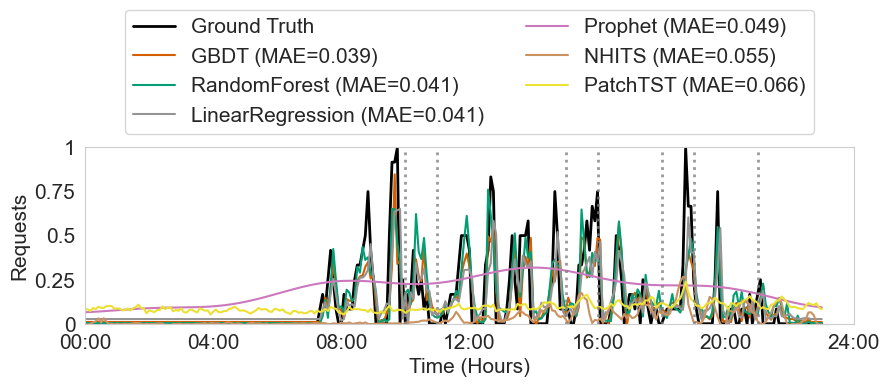

In [4]:
#Figure 11 - Workload Forecasting
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path(".")
START, END = "1970-01-13 05:00", "1970-01-14 04:00"
ORIGINAL_MAE = {"GBDT": 0.039261, "RandomForest": 0.040640, "LinearRegression": 0.041352,
                "Prophet": 0.049394, "NHITS": 0.055602, "PatchTST": 0.065310}

legend_mae = "validation"
out = ROOT / "plots" / "Figure-11.pdf"

P = pd.read_csv(ROOT / "Simulator" / "scripts" / "timeseries_benchmark" / "results" / "test_predictions.csv", index_col="datetime", parse_dates=True)
if legend_mae == "validation":
    mae = pd.read_csv(ROOT / "Simulator" / "scripts" / "timeseries_benchmark" / "results" / "validation_metrics.csv", index_col="model")["MAE_norm"].to_dict()
elif legend_mae == "test_window":
    mae = pd.read_csv(ROOT / "Simulator" / "scripts" / "timeseries_benchmark" / "results" / "test_metrics.csv", index_col="model")["MAE_window_norm"].to_dict()
else:
    mae = ORIGINAL_MAE

w = P.loc[START:END]
norm = w / w["truth"].max()

palette = sns.color_palette("colorblind")
color = {"GBDT": palette[3], "RandomForest": palette[2], "LinearRegression": palette[7],
         "Prophet": palette[4], "NHITS": palette[5], "PatchTST": palette[8]}

plt.figure(figsize=(9, 4))
sns.set_style("whitegrid")
plt.plot(norm.index, norm["truth"].values, color="black", linewidth=2, label="Ground Truth")
for m in ["GBDT", "RandomForest", "LinearRegression", "Prophet", "NHITS", "PatchTST"]:
    plt.plot(norm.index, norm[m].values, color=color[m], label=f"{m} (MAE={mae[m]:.3f})")

ax = plt.gca()
base_ts = pd.to_datetime(START)
for h in [10, 11, 15, 16, 18, 19, 21]:
    plt.axvline(x=base_ts + pd.to_timedelta(h, unit="h"), color="grey", linestyle=":", linewidth=2, alpha=0.8)
hours = list(range(0, 25, 4))
ticks = [base_ts + pd.to_timedelta(h, unit="h") for h in hours]
ax.set_xticks(ticks); ax.set_xticklabels([f"{h:02d}:00" for h in hours], fontsize=15)
ax.set_xlim(ticks[0], ticks[-1])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1]); ax.set_yticklabels(["0", "0.25", "0.5", "0.75", "1"], fontsize=15)
ax.set_ylim(0, 1)
ax.set_xlabel("Time (Hours)", fontsize=15); ax.set_ylabel("Requests", fontsize=15)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=15)
plt.grid(False)
plt.tight_layout()
plt.savefig(out, dpi=200)
#print("saved", out, "| legend MAE:", legend_mae)